# Bibliotecas

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
import re

In [2]:
# Graficas
import matplotlib.pyplot as plt
from matplotlib import cycler
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
# Escalamiento
from sklearn.preprocessing import StandardScaler

# Componentes principales
from sklearn.decomposition import PCA

# Modelo de clustering
from sklearn.cluster import KMeans

# Métricas para selección de clusters
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

# Pruebas estadísticas
from scipy.stats import kruskal

# Cargar datos

In [4]:
songs1 = pd.read_csv(r'https://raw.githubusercontent.com/Wsm-erick/Diplomado/refs/heads/main/Modulo-I/Datasets/features_songs.csv')

In [5]:
songs1.shape

(175, 40)

In [6]:
songs1.head()

,archivo,duration,rms,tempo,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_contrast,mfcc_1,...,chroma_9,chroma_10,chroma_11,chroma_12,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6
0,02 Maroon.mp3,218.305306,0.269286,[107.66601562],0.030423,2131.429071,3054.294473,4833.956751,21.985519,-165.31206,...,0.601635,0.531422,0.506995,0.518395,0.275898,0.210128,0.175254,0.011638,0.049738,-0.057944
1,03 Anti-Hero.mp3,200.724898,0.251603,[97.50884434],0.042470,2270.523020,2887.932364,4680.853820,20.961313,-116.05038,...,0.481668,0.461698,0.506635,0.596817,0.067301,-0.201125,-0.039244,0.056137,0.023695,-0.028362
2,04 Snow On The Beach.mp3,256.156735,0.191276,[109.95678191],0.026679,1691.923217,2516.562246,3338.831279,21.885129,-205.33786,...,0.507185,0.615904,0.499524,0.530878,0.140940,-0.188128,-0.098086,-0.042389,0.013691,-0.021691
3,"05 You_re On Your Own, Kid.mp3",194.246531,0.261242,[120.18531977],0.021683,1637.701889,2600.810313,3373.619237,21.883741,-183.35786,...,0.440590,0.486334,0.450555,0.462748,0.128289,0.005553,0.065578,-0.140425,0.006879,0.009277
4,06 Midnight Rain.mp3,174.837551,0.226225,[69.83741554],0.021928,1485.590595,2261.139587,3117.497364,21.791955,-223.94078,...,0.479455,0.510774,0.485107,0.532159,0.107616,0.223978,-0.027103,0.086051,0.020835,0.057351


# Descripción de las variables

![variables](songs_var_description.png)

# Actividad

![actividad](songs_activity.png)

# Exploración

## Tipo de dato por variable

In [7]:
songs1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   archivo             175 non-null    object 
 1   duration            175 non-null    float64
 2   rms                 175 non-null    float64
 3   tempo               175 non-null    object 
 4   zcr                 175 non-null    float64
 5   spectral_centroid   175 non-null    float64
 6   spectral_bandwidth  175 non-null    float64
 7   spectral_rolloff    175 non-null    float64
 8   spectral_contrast   175 non-null    float64
 9   mfcc_1              175 non-null    float64
 10  mfcc_2              175 non-null    float64
 11  mfcc_3              175 non-null    float64
 12  mfcc_4              175 non-null    float64
 13  mfcc_5              175 non-null    float64
 14  mfcc_6              175 non-null    float64
 15  mfcc_7              175 non-null    float64
 16  mfcc_8  

## Valores ausentes

In [8]:
def is_na_df(df):
    #Establecemos el resumen de NAs por columna
    na_summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "columna", 0: "n_missing"})
    )

    #Tomamos totales y prporciones
    na_summary["total"] = len(df)
    na_summary["prop_missing"] = na_summary["n_missing"] / na_summary["total"]
    na_summary["prop_original"] = 1 - na_summary["prop_missing"]

    #Filtramos solo columnas con al menos 1 NA
    na_summary = na_summary[na_summary["n_missing"] > 0].reset_index(drop=True)

    #Agregamos fila resumen global
    total_missing = df.isna().sum().sum()
    total_elements = df.size
    prop_missing_global = total_missing / total_elements
    prop_original_global = 1 - prop_missing_global

    resumen = pd.DataFrame({
        "columna": ["TOTAL"],
        "n_missing": [total_missing],
        "total": [total_elements],
        "prop_missing": [prop_missing_global],
        "prop_original": [prop_original_global]
    })

    #Creamos la tabla
    na_summary = pd.concat([na_summary, resumen], ignore_index=True)

    return na_summary

In [9]:
is_na_df(songs1)

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,7000,0.0,1.0


No hay valores ausentes por lo que no hace falta aplicar un método de imputación.

## Distribución de variables numéricas

In [10]:
var_cat = songs1.select_dtypes(['object']).columns.tolist()
var_cat

['archivo', 'tempo']

In [11]:
songs1['tempo_num'] = songs1['tempo'].str[1:-1].astype(float)

In [12]:
def guess_lang_heuristic(text: str):

    spanish_words = {
        "el","la","los","las","un","una","unos","unas","de","del","al","y","o","u",
        "que","como","con","por","para","sin","sobre","entre","más","menos","mi","tu",
        "te","se","me","lo","le","su","si","ya","no","sí","a","en"
    }

    tokens = {t for t in re.findall(r"\b\w+\b", text)}
    hits = len(tokens & spanish_words)
    
    # si tiene acentos/símbolos muy comunes en español, suma
    accent_bonus = 1 if re.search(r"[áéíóúñü]", text.lower()) else 0
    score_es = hits + accent_bonus
    
    # título muy corto => baja confianza
    conf = min(1.0, 0.2*score_es + 0.2*(len(tokens) >= 3))
    if score_es >= 2:
        return "es", conf

    # si no hay indicios en español y tiene muchas palabras comunes en inglés
    english_words = {"the","and","you","your","i","me","my","on","in","with","for","of","to","from","at","it","is"}
    hits_en = len(tokens & english_words)
    if hits_en >= 2:
        return "en", max(conf, 0.6)
        
    # por defecto “en” si todo está en ASCII y sin acentos; si no, desconocido
    return ("en", 0.5) if text.isascii() else ("unk", 0.3)

In [13]:
def label_from_code(code):
    return {"es":"Español","en":"Inglés","unk":"Desconocido"}.get(code,"Desconocido")

In [14]:
songs1['archivo'] = songs1['archivo'].str.replace('.mp3' , '').str.lower()

In [15]:
songs1['archivo'].to_csv('canciones.csv')

In [16]:
songs1["lang_code"], songs1["lang_conf"] = zip(*songs1["archivo"].map(guess_lang_heuristic))
songs1["lang"] = songs1["lang_code"].map(label_from_code)

In [17]:
songs1.head(3)

,archivo,duration,rms,tempo,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_contrast,mfcc_1,...,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6,tempo_num,lang_code,lang_conf,lang
0,02 maroon,218.305306,0.269286,[107.66601562],0.030423,2131.429071,3054.294473,4833.956751,21.985519,-165.31206,...,0.275898,0.210128,0.175254,0.011638,0.049738,-0.057944,107.666016,en,0.5,Inglés
1,03 anti-hero,200.724898,0.251603,[97.50884434],0.042470,2270.523020,2887.932364,4680.853820,20.961313,-116.05038,...,0.067301,-0.201125,-0.039244,0.056137,0.023695,-0.028362,97.508844,en,0.5,Inglés
2,04 snow on the beach,256.156735,0.191276,[109.95678191],0.026679,1691.923217,2516.562246,3338.831279,21.885129,-205.33786,...,0.140940,-0.188128,-0.098086,-0.042389,0.013691,-0.021691,109.956782,en,0.6,Inglés


In [18]:
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas (cada una en figura independiente)
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{var} - Boxplot", f"{var} - Histograma"))

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#008080"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             #marker_color="#00a77d", 
                             #marker_color='#722F37',
                             marker_color="rgba(114, 47, 55, 0.5)",  # burdeos con 50% transparencia
                             nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable numérica: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        n = len(self.cat_vars)
        cols = 2
        rows = (n + 1) // cols if n > 1 else 1

        fig = make_subplots(
            rows=rows, cols=cols,
            specs=[[{'type':'domain'}]*cols for _ in range(rows)],
            subplot_titles=self.cat_vars
        )

        for i, var in enumerate(self.cat_vars):
            row = i // cols + 1
            col = i % cols + 1

            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            wine_palette = [
                "#722F37", "#B85042", "#E6AF2E", "#F6D55C", "#F4A7B9",
                "#2F4F4F", "#8D6E63", "#A1887F", "#D7CCC8", "#795548"
            ]
            
            fig.add_trace(
                go.Pie(
                    labels=labels, 
                    values=values, 
                    name=var, 
                    textinfo='percent+label',
                    marker=dict(colors=wine_palette)
                ),
                row=row, col=col
            )

            #fig.add_trace(
            #    go.Pie(labels=labels, values=values, name=var, textinfo='percent+label'),
            #    row=row, col=col
            #)

        fig.update_layout(title_text="Variables Categóricas", height=400*rows)
        fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self, color: str, values: bool = True):
        corr_matrix = self.df[self.num_vars].corr()

        if values:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color,
                text=corr_matrix.round(1).values,      # valores de correlación con 1 decimal
                texttemplate="%{text}",                # mostrar texto en cada celda
                textfont={"size":10, "color":"black"}  # estilo de fuente
                ))
        else:
            fig = go.Figure(data=go.Heatmap(
                z=corr_matrix.values,
                x=corr_matrix.columns,
                y=corr_matrix.columns,
                colorscale=color
                ))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [19]:
var_cat = songs1.select_dtypes('object').columns.tolist()
var_num = list(set(songs1.columns)-set(var_cat))
var_cat

['archivo', 'tempo', 'lang_code', 'lang']

In [20]:
analisis = analyze(songs1, var_num, ['lang'])

In [21]:
songs1.describe()

,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_contrast,mfcc_1,mfcc_2,mfcc_3,...,chroma_11,chroma_12,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6,tempo_num,lang_conf
count,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,...,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000
mean,242.625580,0.178263,0.058199,2648.488772,2988.567941,5473.065749,21.801889,-158.931074,140.614699,-26.212339,...,0.456177,0.466682,0.040485,0.032733,0.013377,0.013172,0.002823,-0.002182,111.935760,0.535429
std,67.956199,0.049730,0.018800,635.439223,500.307972,1397.766313,0.858255,38.227926,21.623594,21.760878,...,0.085315,0.070548,0.103817,0.102631,0.069900,0.077798,0.019156,0.021415,22.777153,0.116962
min,124.240000,0.055421,0.018877,1036.709252,1320.658488,1975.675843,19.465870,-276.422400,85.240814,-75.233640,...,0.237338,0.254564,-0.222699,-0.293091,-0.228473,-0.211357,-0.046127,-0.063731,69.837416,0.300000
25%,191.916952,0.138568,0.044932,2252.657618,2654.740590,4612.901963,21.283166,-181.099535,125.182952,-42.279401,...,0.405111,0.425203,-0.032431,-0.028935,-0.037906,-0.042667,-0.009250,-0.014530,97.508844,0.500000
50%,229.111293,0.178693,0.057285,2645.661730,2989.998973,5520.686528,21.773645,-154.530210,139.702700,-26.979185,...,0.461059,0.466638,0.036603,0.038114,0.008709,0.019528,0.004239,-0.002709,107.666016,0.500000
75%,280.912120,0.209344,0.071291,3040.246637,3308.289221,6251.972851,22.263098,-133.741050,155.288480,-15.626485,...,0.508748,0.517050,0.122870,0.099992,0.053448,0.068193,0.012924,0.011443,120.185320,0.600000
max,472.201020,0.307894,0.106914,4261.901169,4387.397055,9319.848099,24.342274,-84.056380,220.203380,36.474575,...,0.642065,0.682561,0.290125,0.262957,0.175254,0.220034,0.049738,0.063773,198.768029,1.000000


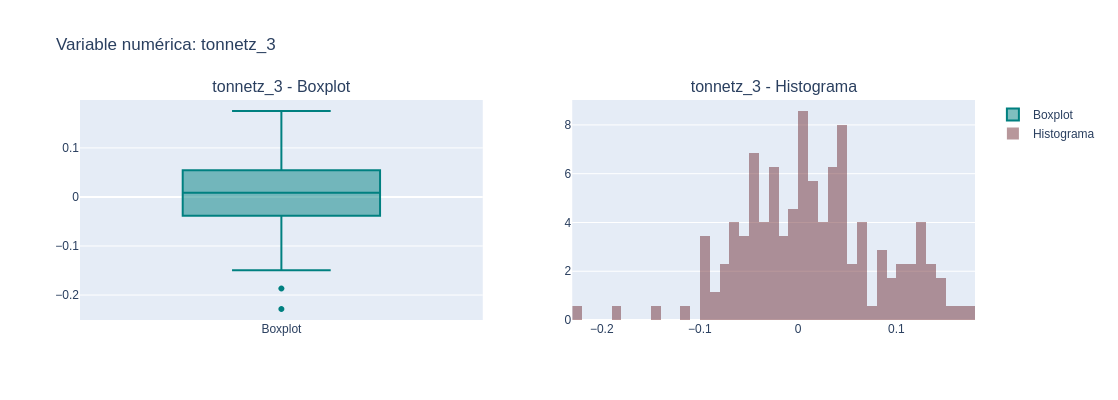

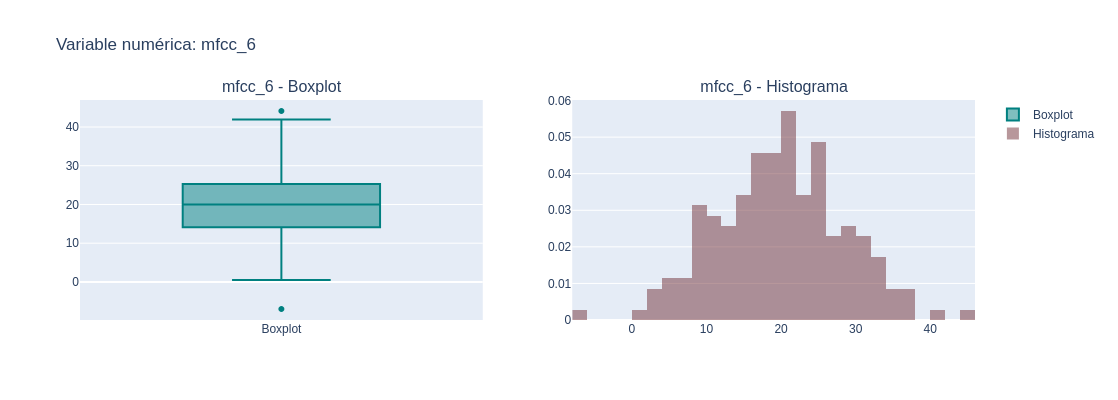

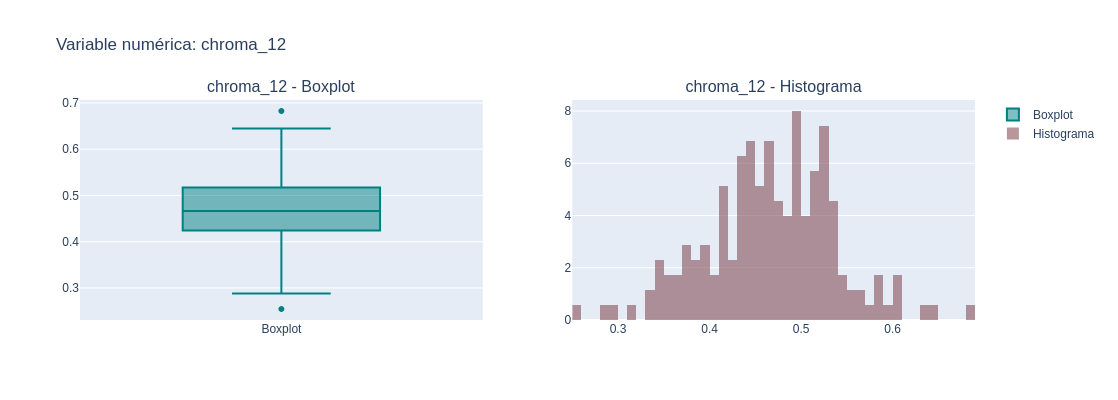

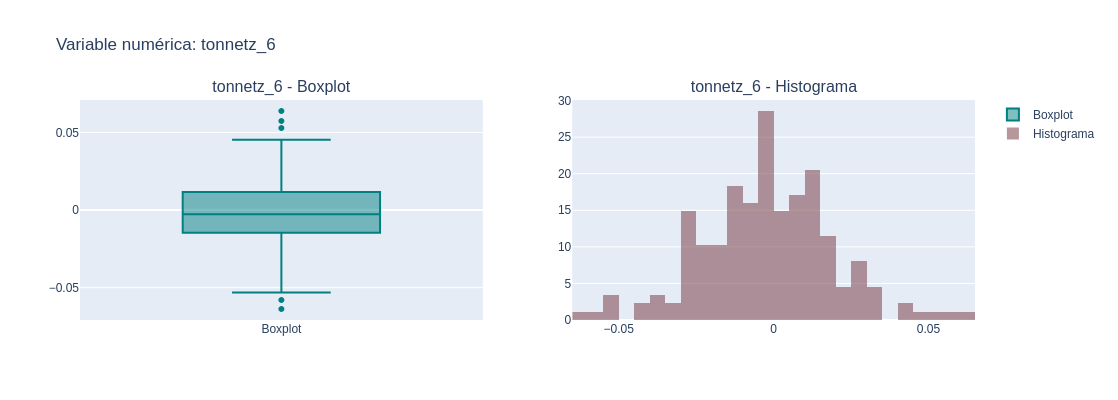

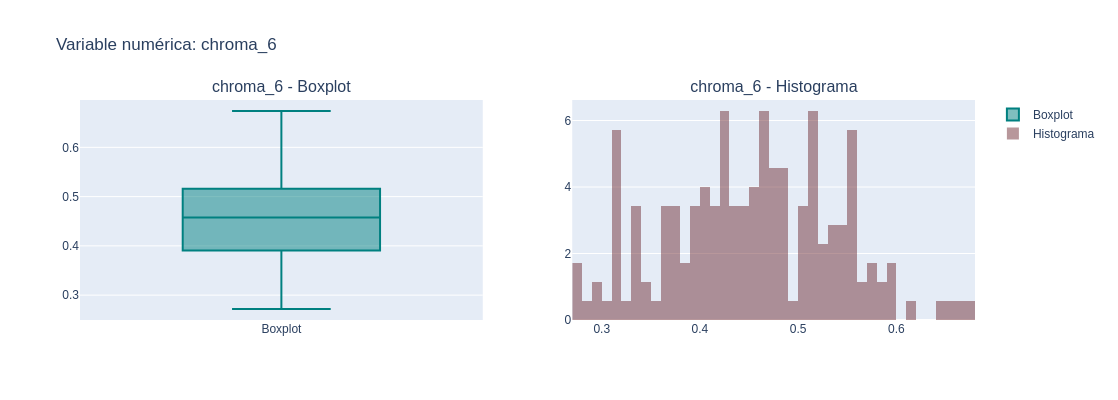

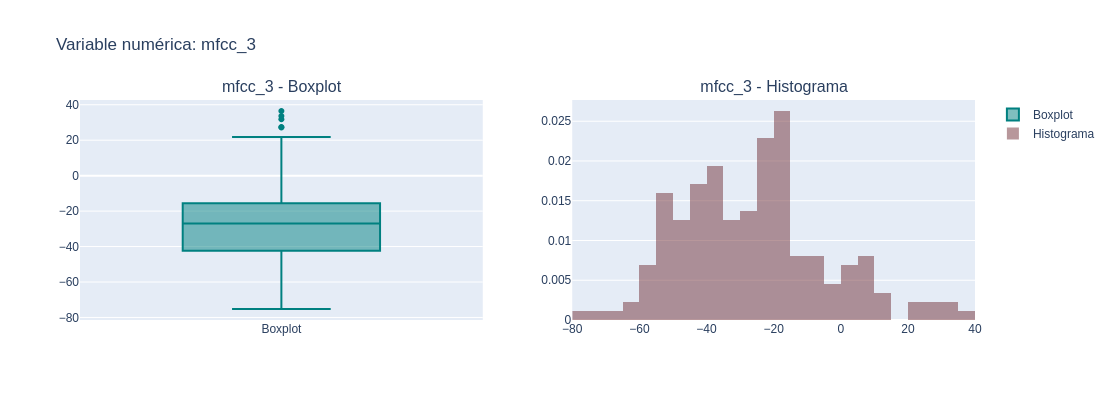

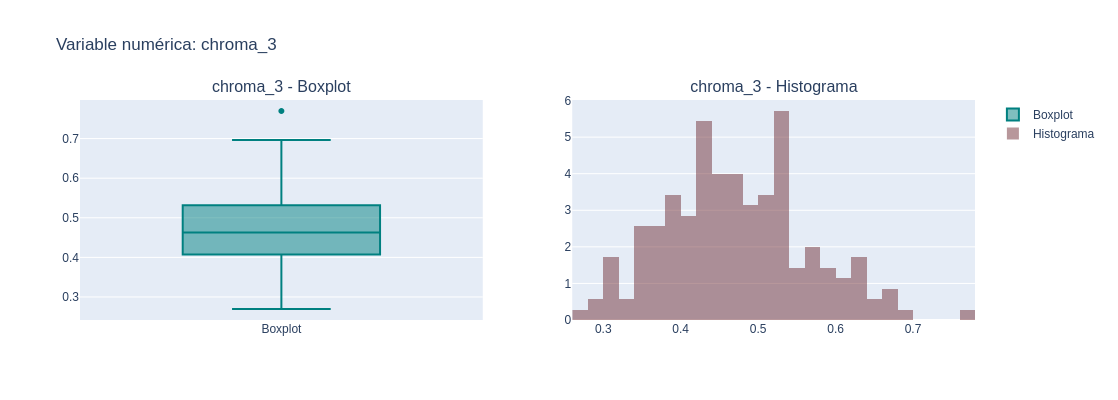

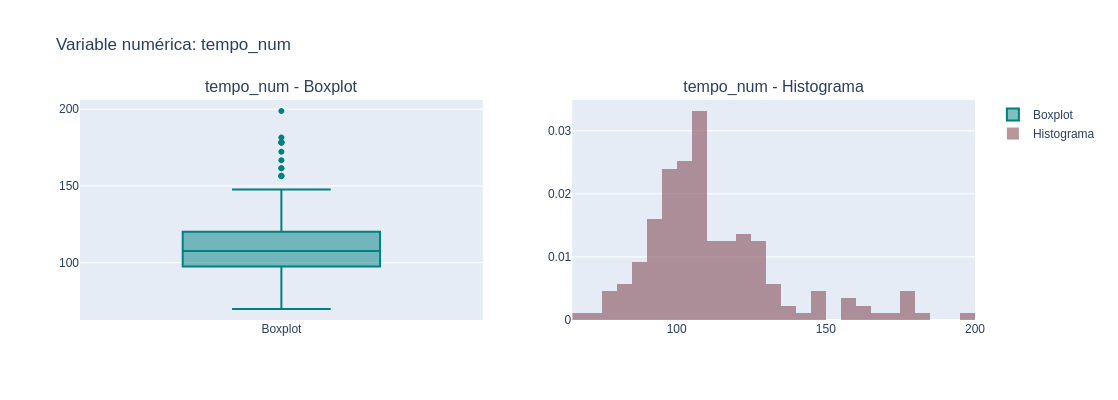

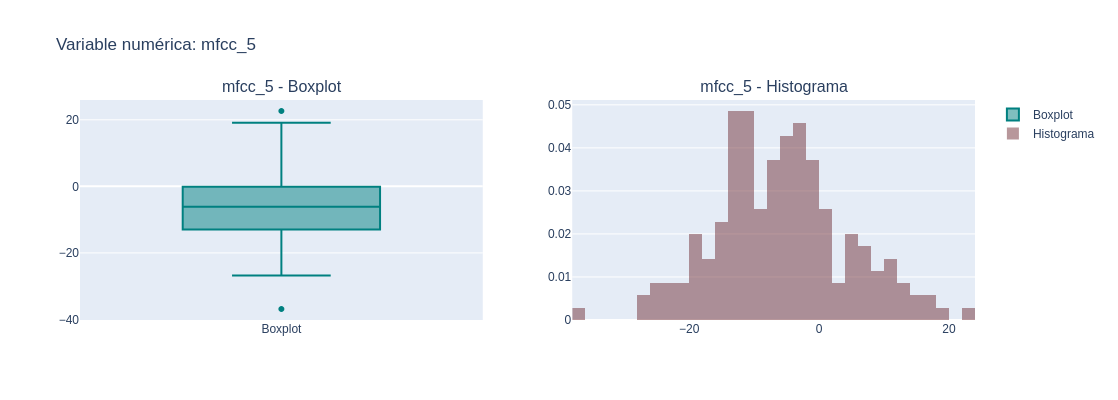

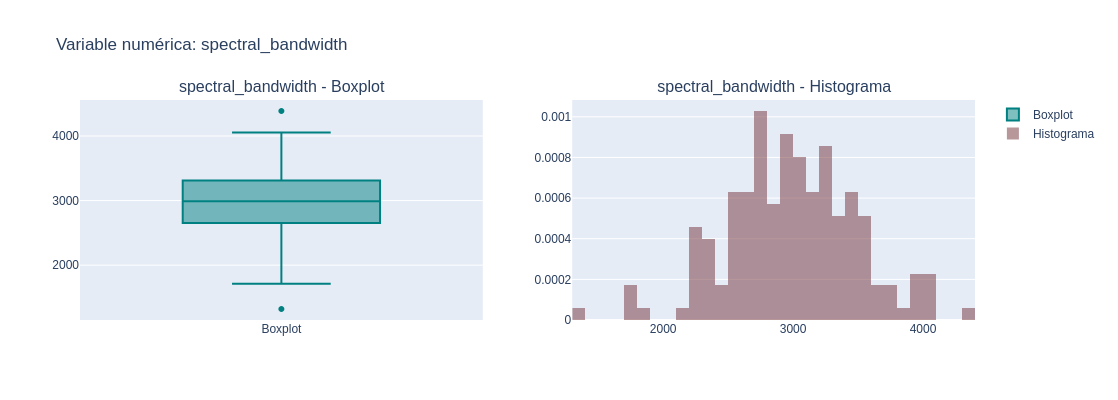

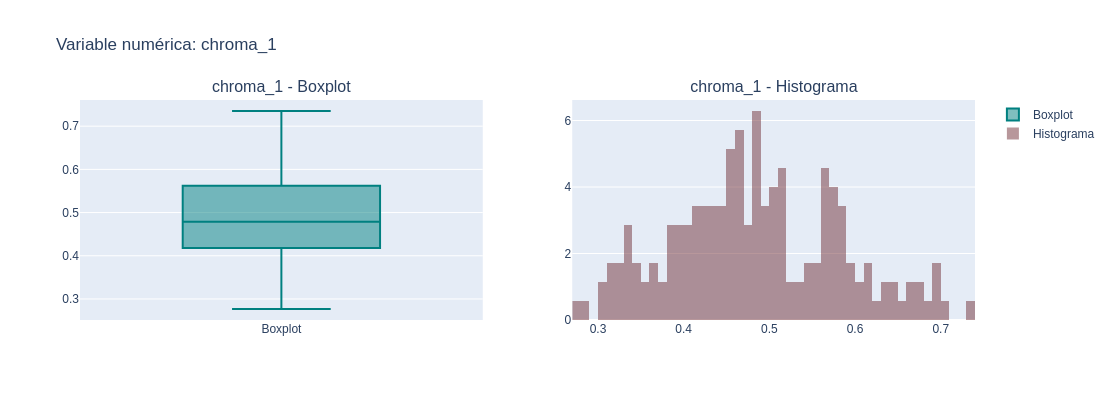

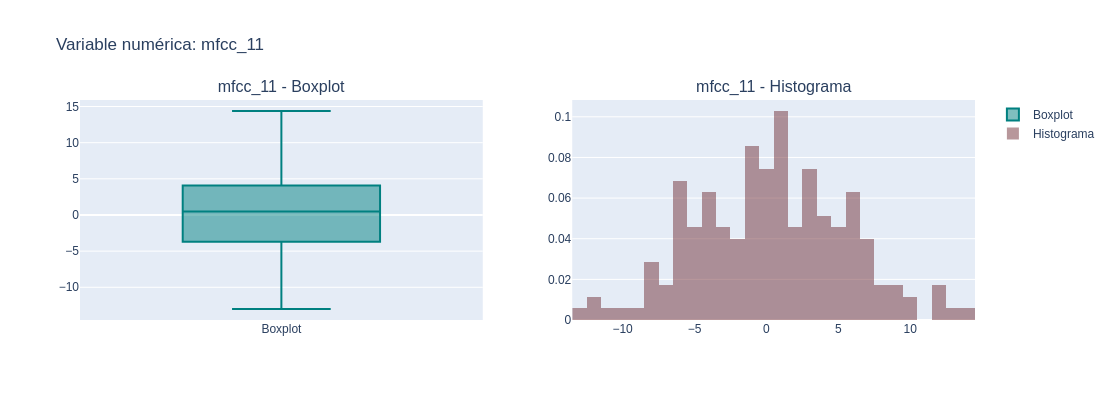

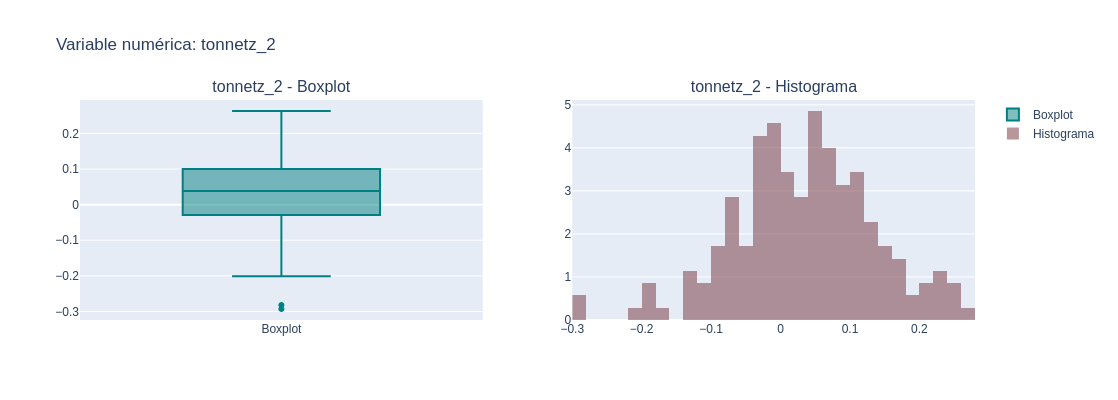

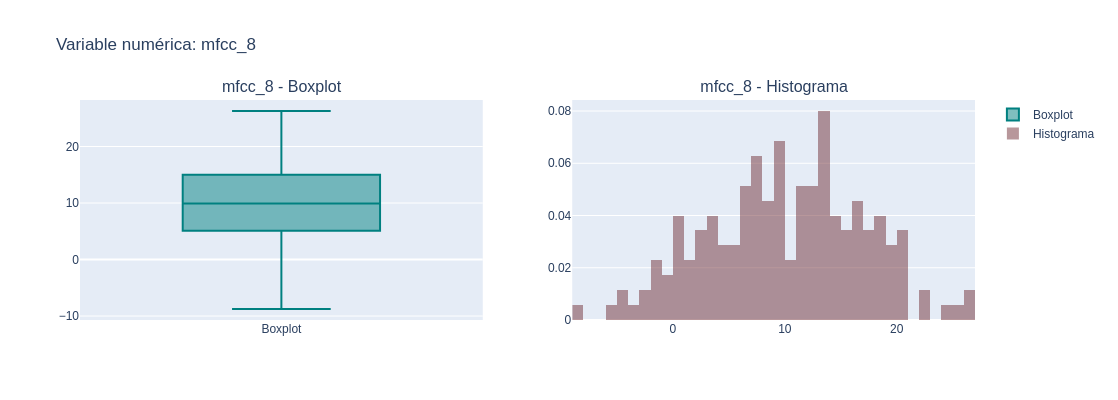

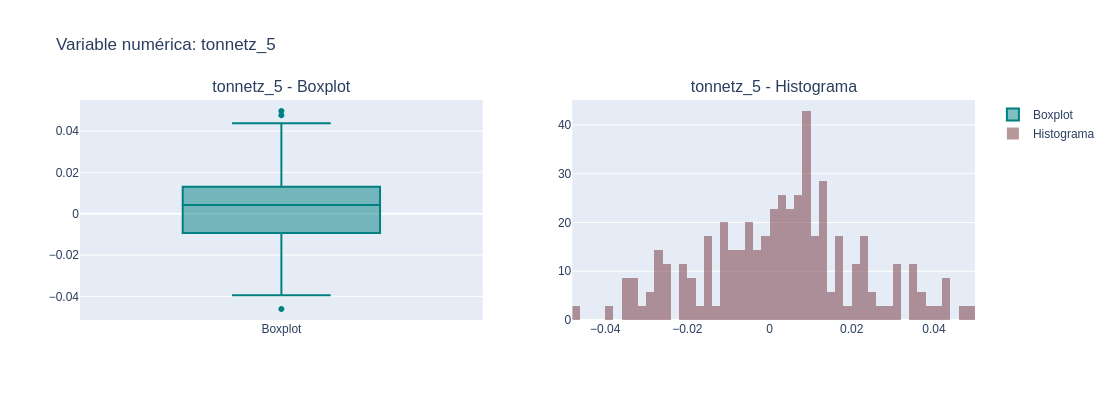

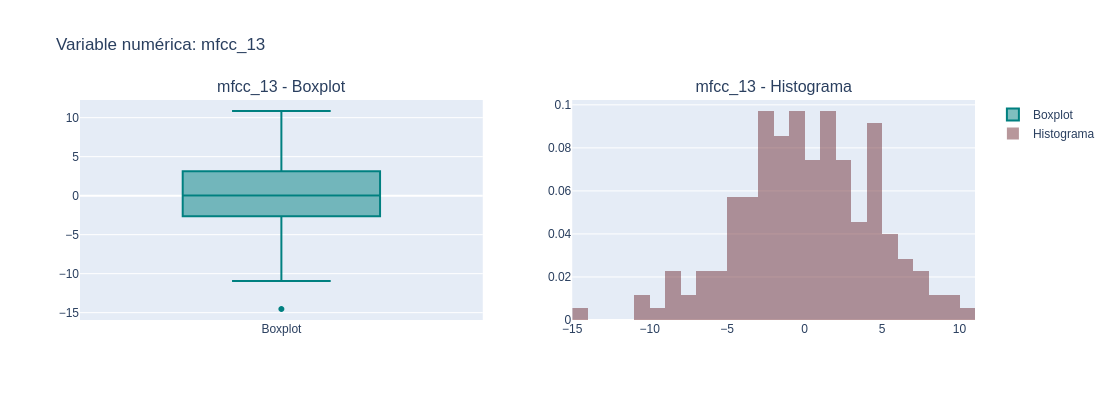

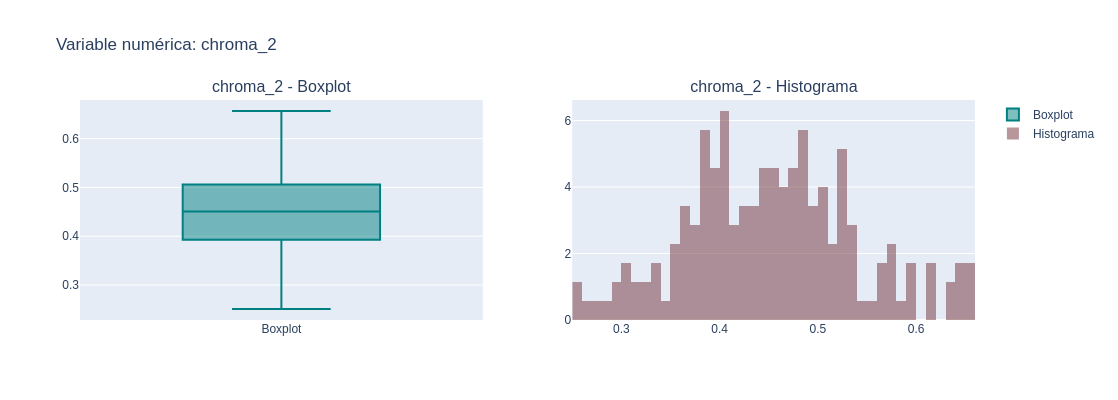

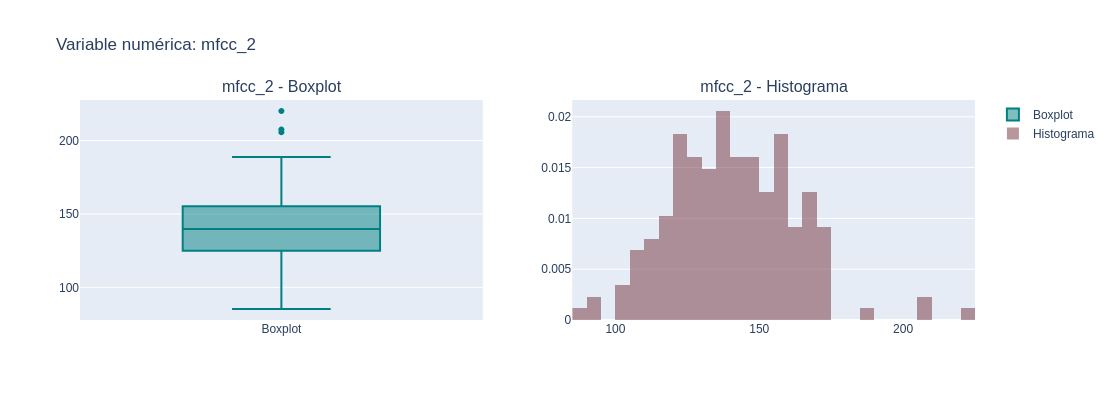

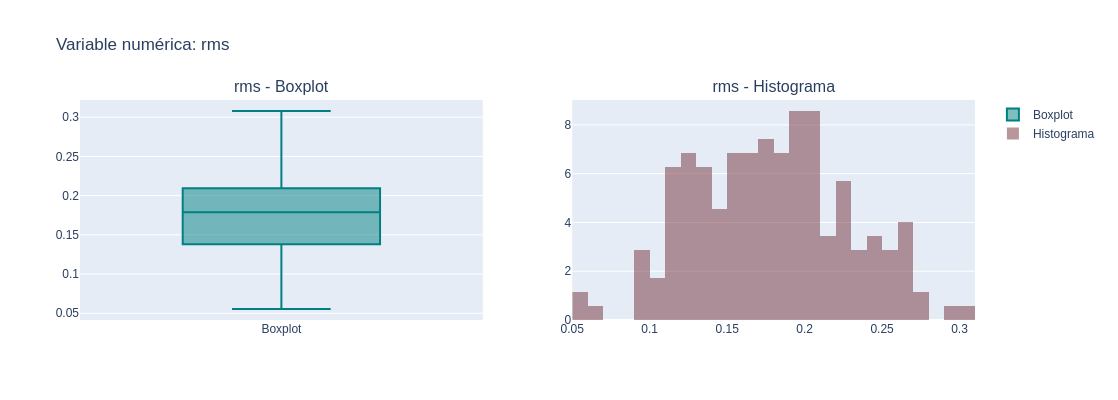

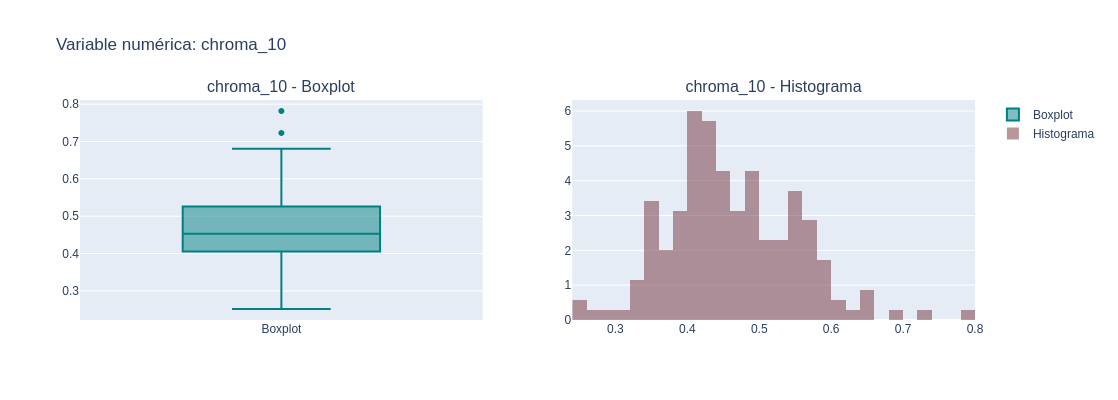

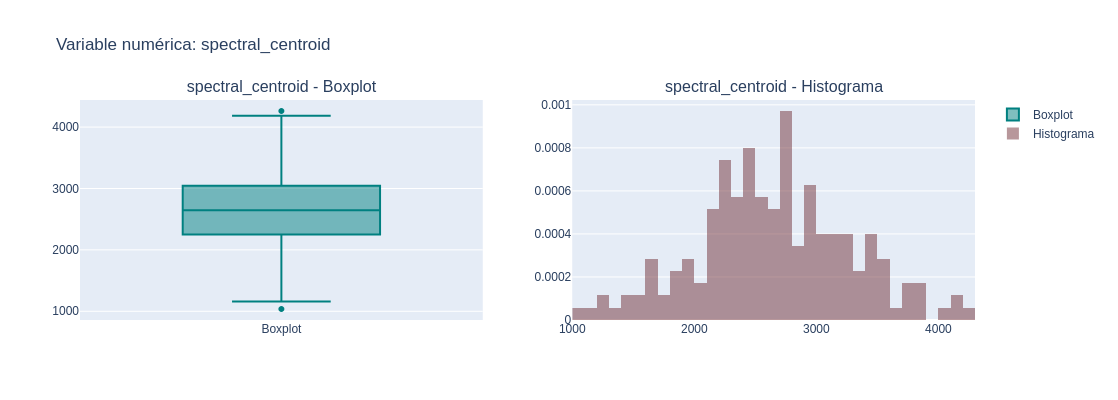

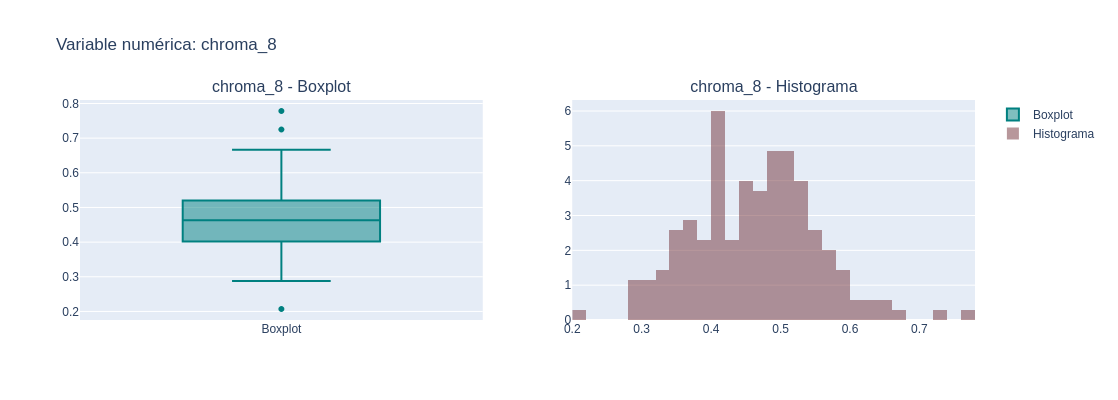

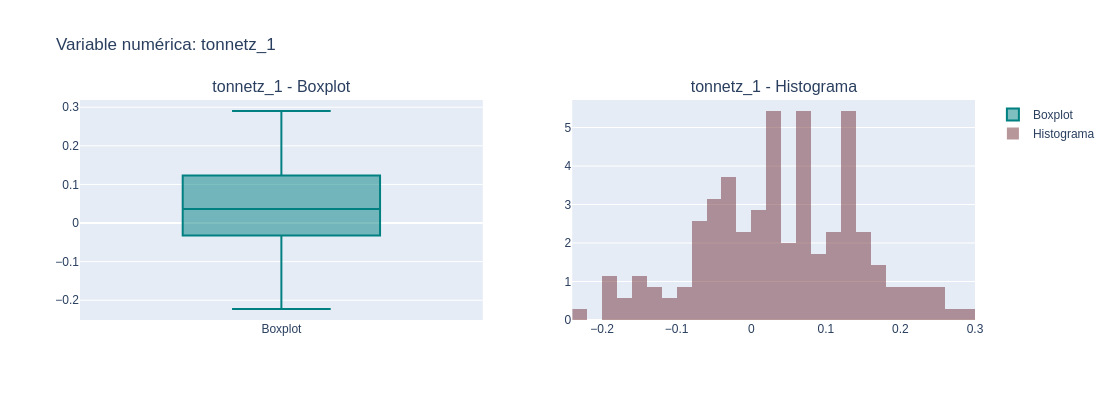

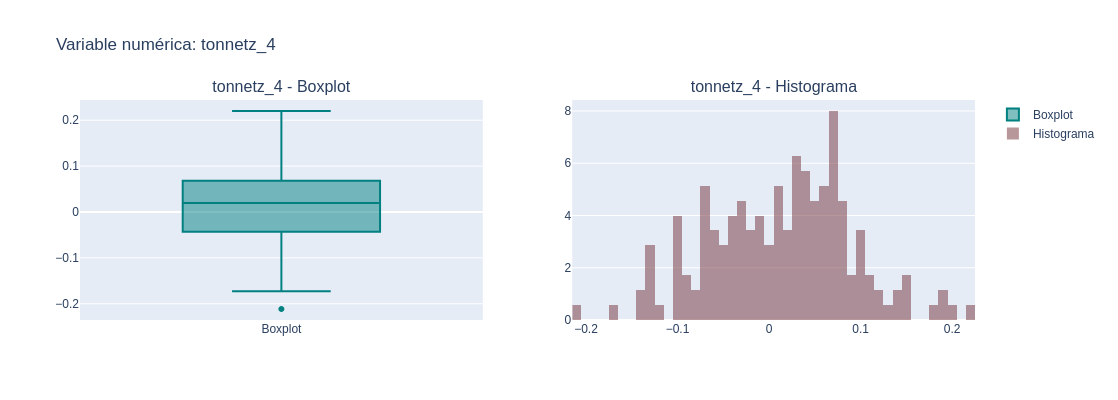

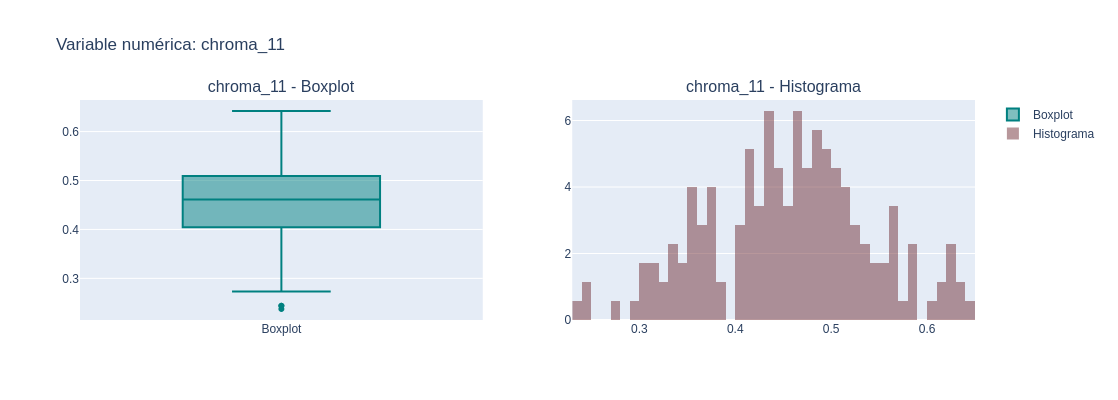

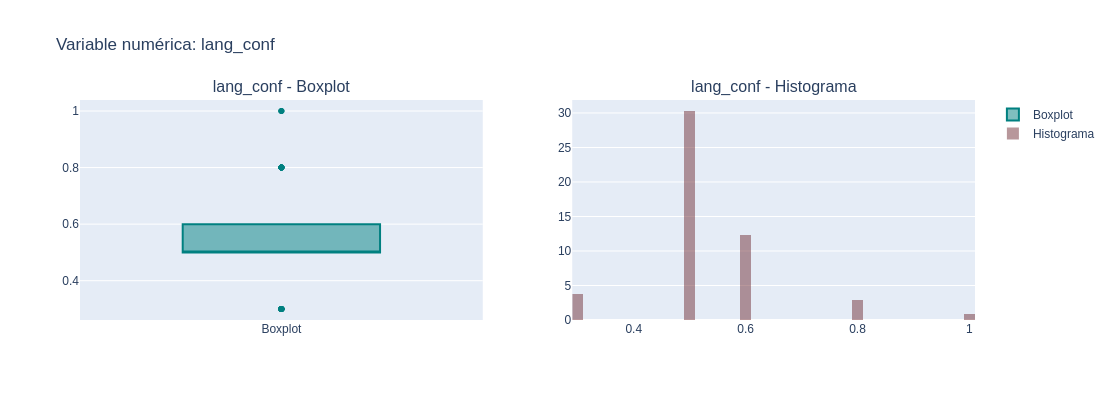

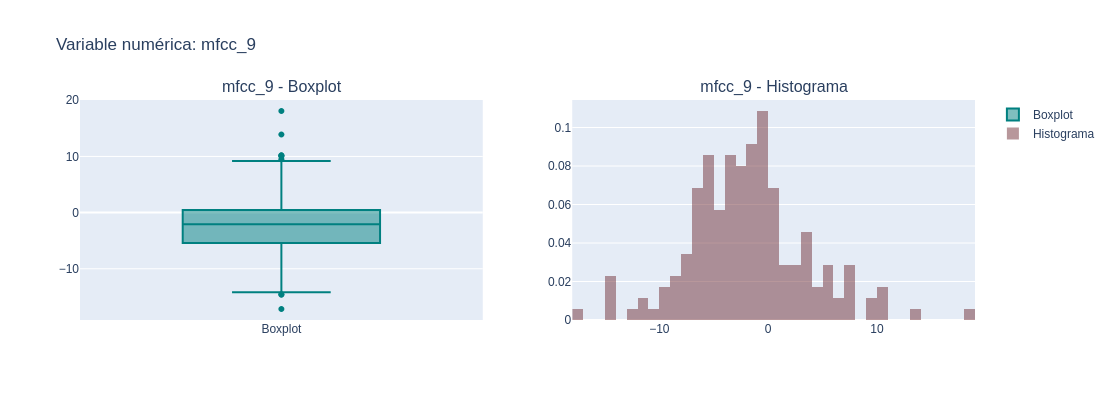

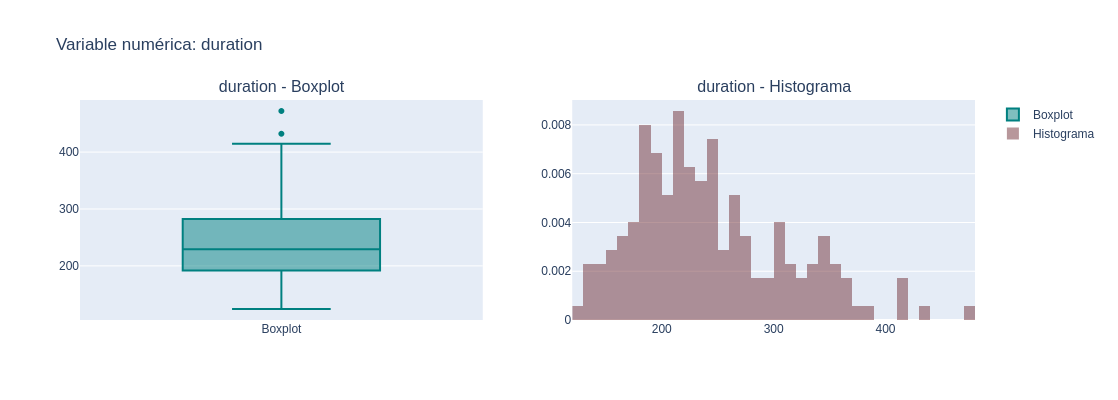

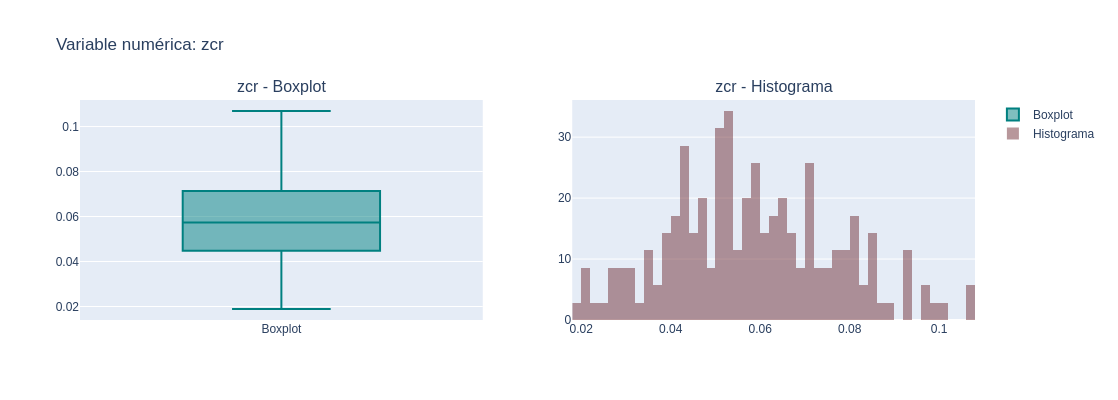

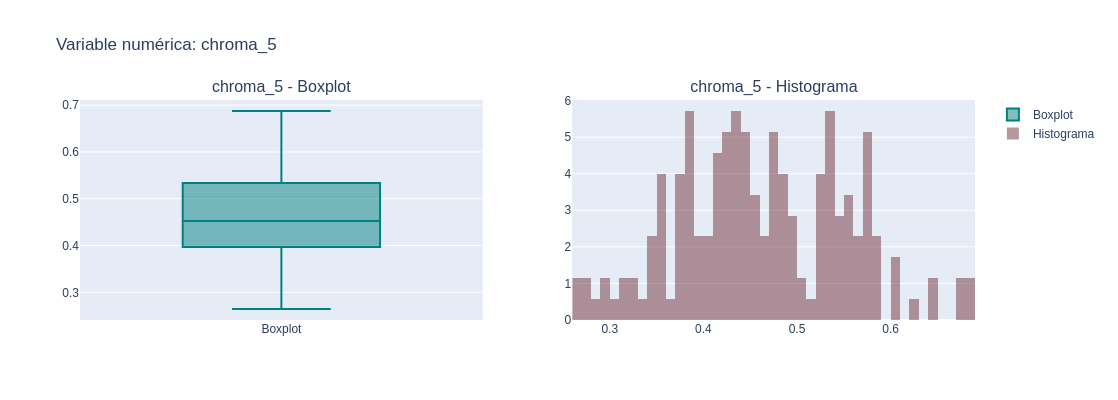

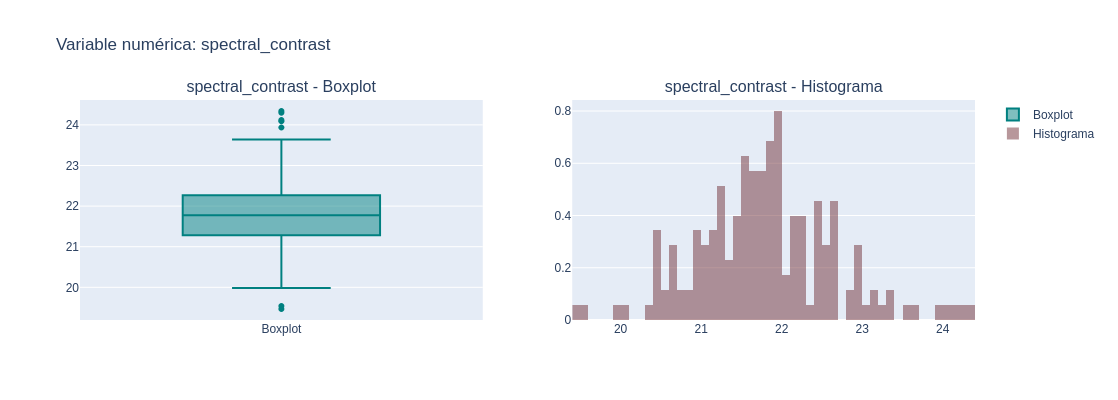

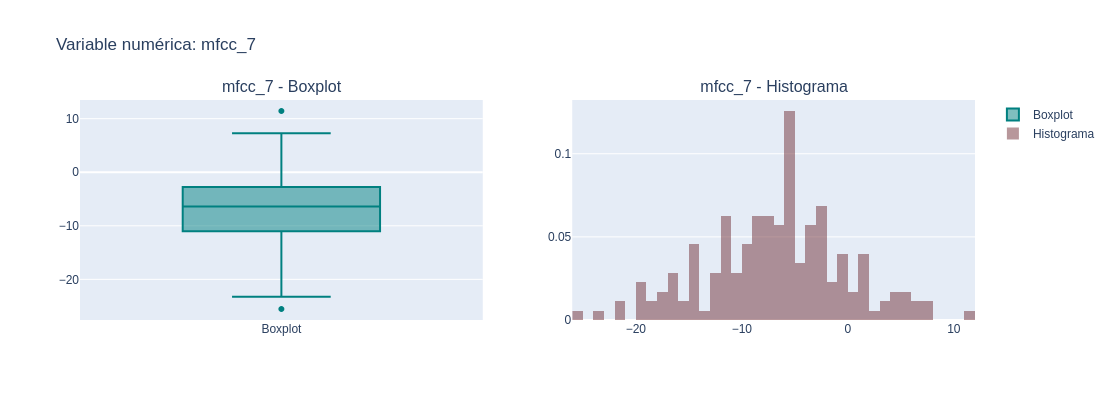

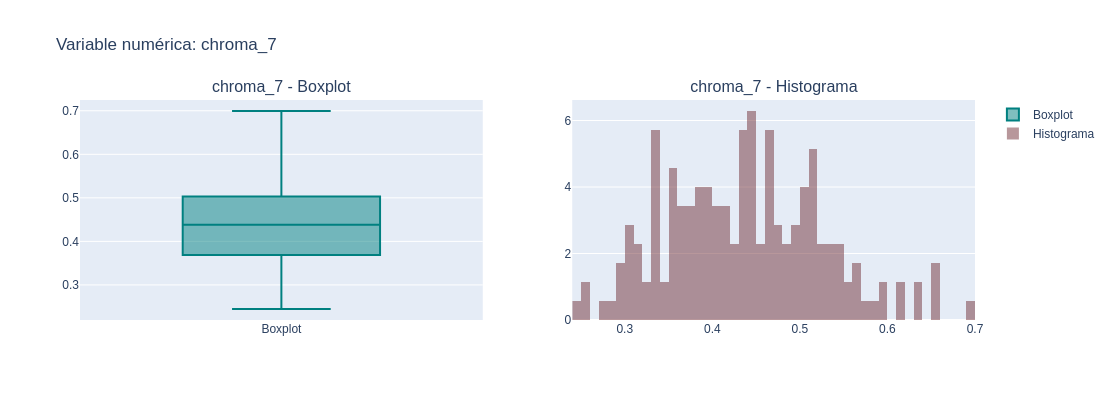

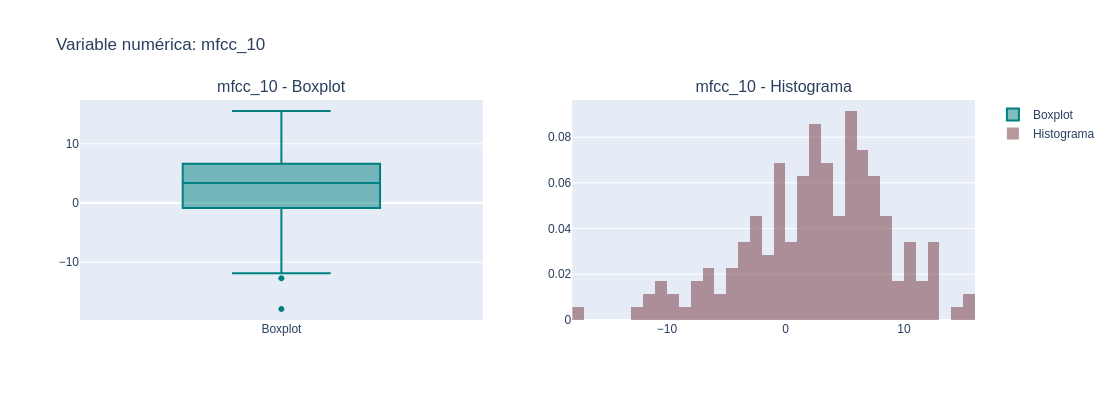

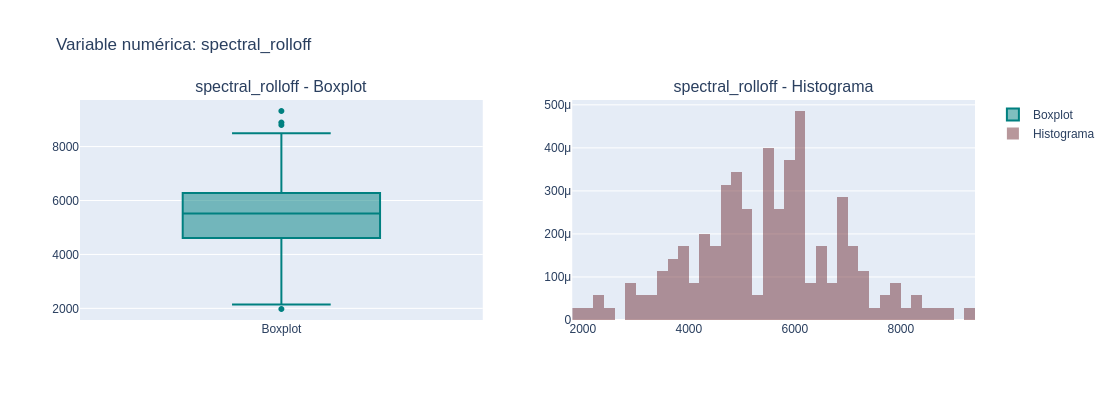

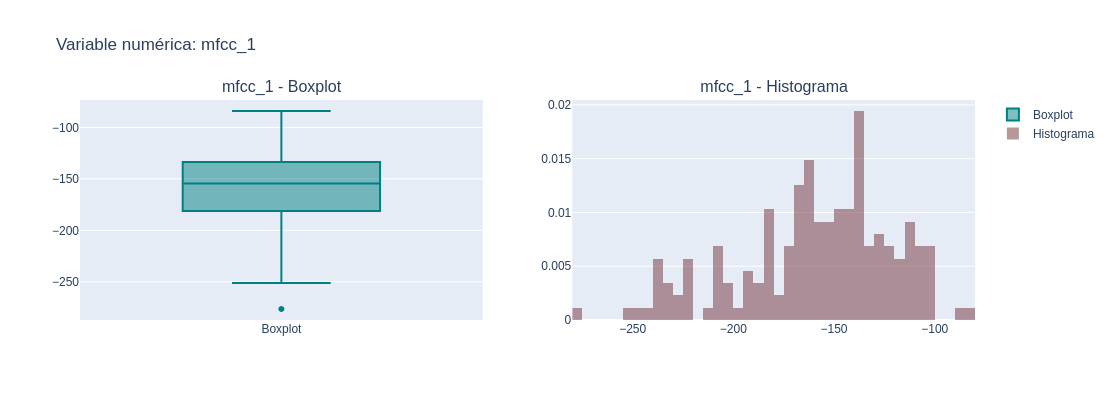

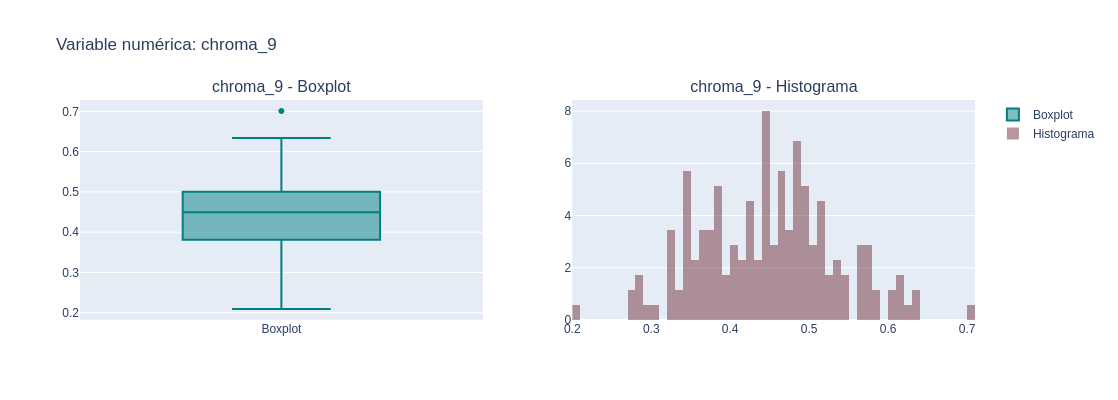

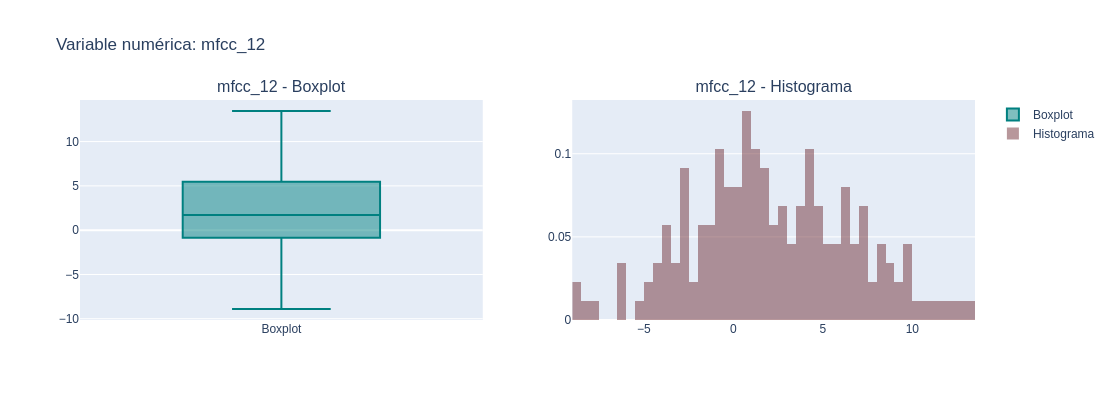

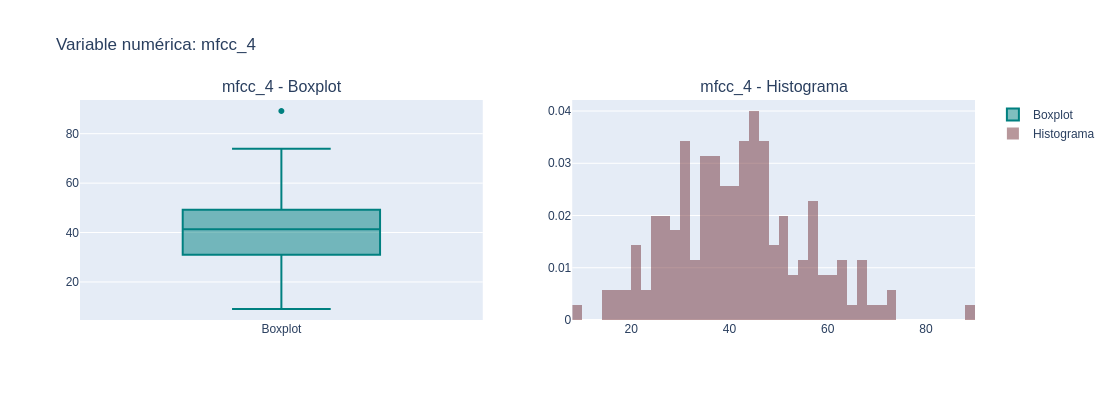

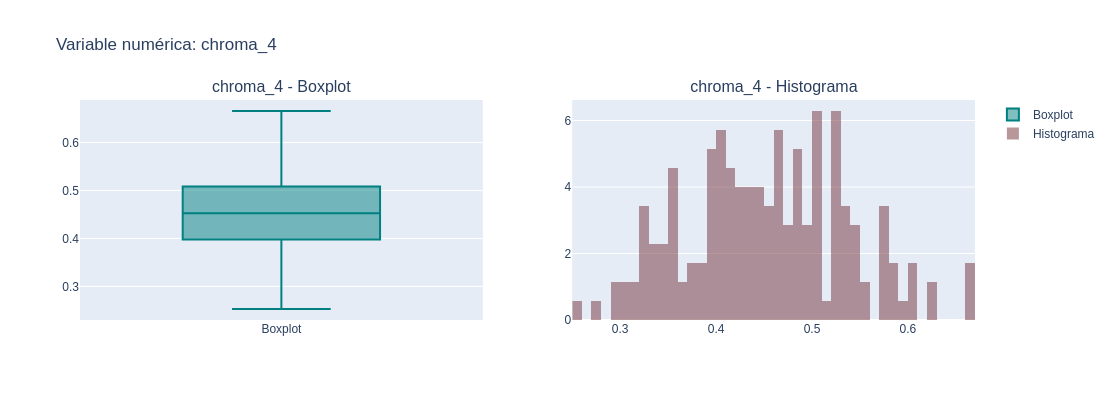

In [22]:
analisis.plot_num()

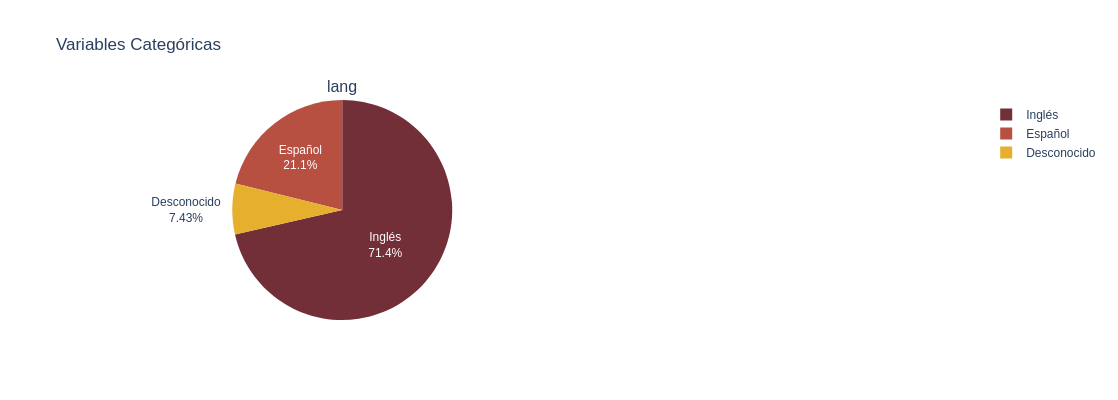

In [23]:
analisis.plot_cat()

In [24]:
songs1.query("lang == 'Desconocido'").shape

(13, 44)

Eliminación de canciones de otro idioma distinto al inglés y al español

In [25]:
songs1.drop(songs1.query("lang == 'Desconocido'").index, inplace=True)

In [26]:
songs1.shape

(162, 44)

# Tratamiento de Datos

## Escalado

In [27]:
colors = ['aggrnyl', 'agsunset', 'algae', 'amp', 'armyrose', 'balance',
             'blackbody', 'bluered', 'blues', 'blugrn', 'bluyl', 'brbg',
             'brwnyl', 'bugn', 'bupu', 'burg', 'burgyl', 'cividis', 'curl',
             'darkmint', 'deep', 'delta', 'dense', 'earth', 'edge', 'electric',
             'emrld', 'fall', 'geyser', 'gnbu', 'gray', 'greens', 'greys',
             'haline', 'hot', 'hsv', 'ice', 'icefire', 'inferno', 'jet',
             'magenta', 'magma', 'matter', 'mint', 'mrybm', 'mygbm', 'oranges',
             'orrd', 'oryel', 'oxy', 'peach', 'phase', 'picnic', 'pinkyl',
             'piyg', 'plasma', 'plotly3', 'portland', 'prgn', 'pubu', 'pubugn',
             'puor', 'purd', 'purp', 'purples', 'purpor', 'rainbow', 'rdbu',
             'rdgy', 'rdpu', 'rdylbu', 'rdylgn', 'redor', 'reds', 'solar',
             'spectral', 'speed', 'sunset', 'sunsetdark', 'teal', 'tealgrn',
             'tealrose', 'tempo', 'temps', 'thermal', 'tropic', 'turbid',
             'turbo', 'twilight', 'viridis', 'ylgn', 'ylgnbu', 'ylorbr',
             'ylorrd']

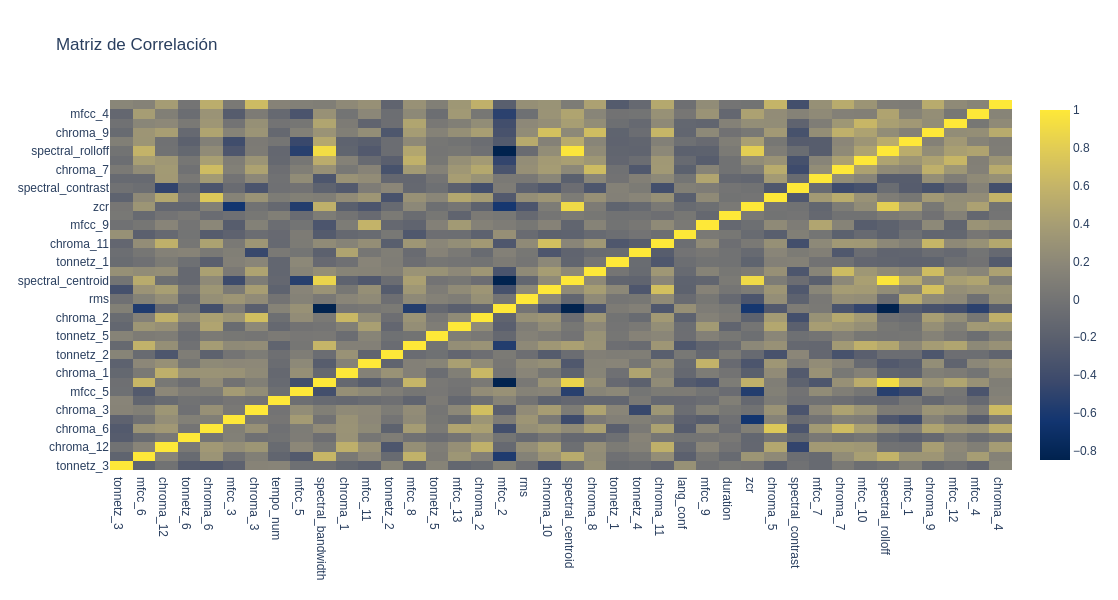

In [28]:
analisis.corr_matrix('cividis', False)

In [29]:
X = songs1.drop(columns=var_cat + ['lang_conf'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Componentes principales

In [30]:
class rPCA:
    #Inicializamos
    def __init__(self, dataframe, cols, n_comp):
        self.dataframe = dataframe
        self.cols = cols
        self.n_comp = n_comp

        if self.cols == None:
            self.dataframe = dataframe
        else:
            self.dataframe = dataframe[cols]

    #Ajustamos el PCA
    def r_pca(self):
        pca = PCA(n_components = self.n_comp)
        pca.fit(self.dataframe)
        self.df_trans = pd.DataFrame(pca.transform(self.dataframe), columns=[f'p_{i}' for i in range(len(pca.explained_variance_ratio_))])
        return self.df_trans, pca.explained_variance_ratio_.cumsum()

    #Diagrama del codo
    def plot_elbow(self):
        pca_temp = PCA().fit(self.dataframe)
        var_exp = pca_temp.explained_variance_ratio_
        cum_var_exp = var_exp.cumsum()

        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(var_exp) + 1), cum_var_exp, marker='o', linestyle='--', color='maroon')
        plt.xlabel('Número de Componentes')
        plt.ylabel('Varianza Acumulada Explicada')
        plt.title('Diagrama de Codo')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [31]:
var_num = [x for x in var_num if x != 'lang_conf']

In [32]:
pca_01 = rPCA(pd.DataFrame(X_scaled, columns=var_num), var_num, 0.90)

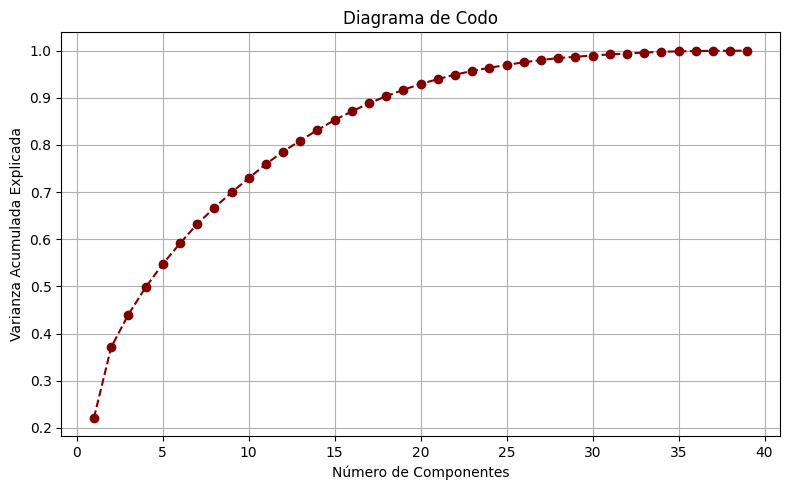

In [33]:
pca_01.plot_elbow()

In [34]:
print("Componentes:", pca_01.r_pca()[0].shape[1])

Componentes: 18


## Vecinos Cercanos

In [35]:
class rKMeans:
    #Inicializamos
    def __init__(self, dataframe, cols=None, max_clusters=10, random_state=42):
        self.cols = cols
        self.max_clusters = max_clusters
        self.random_state = random_state
        self.df = dataframe if cols is None else dataframe[cols]
        self.model = None
        self.labels_ = None
        self.centroids_ = None
        self.df_plot = None

    def optimal_clusters(self, random_state: int | None = None, plot: bool = True):

        if random_state is None:
            random_state = self.random_state
        
        silhouette_scores = []
        inertias = []
        calinski_scores = []
        davies_scores = []

        K = range(2, self.max_clusters + 1)

        for k in K:
            km = KMeans(n_clusters=k, random_state=random_state)
            labels = km.fit_predict(self.df)

            silhouette_scores.append(silhouette_score(self.df, labels))
            inertias.append(km.inertia_)
            calinski_scores.append(calinski_harabasz_score(self.df, labels))
            davies_scores.append(davies_bouldin_score(self.df, labels))

        df_eval = pd.DataFrame({
            'Clusters': list(K),
            'Silueta': silhouette_scores,
            'Inercia': inertias,
            'Calinski-Harabasz': calinski_scores,
            'Davies-Bouldin': davies_scores
        })

        if plot:
            fig, ax = plt.subplots(2, 2, figsize=(14, 10))

            ax[0, 0].plot(K, silhouette_scores, marker='o', color='blue')
            ax[0, 0].set_title('Coeficiente de Silueta')
            ax[0, 0].set_xlabel('Número de Clusters')
            ax[0, 0].set_ylabel('Silueta')

            ax[0, 1].plot(K, inertias, marker='o', color='green')
            ax[0, 1].set_title('Inercia')
            ax[0, 1].set_xlabel('Número de Clusters')
            ax[0, 1].set_ylabel('Inercia')

            ax[1, 0].plot(K, calinski_scores, marker='o', color='navy')
            ax[1, 0].set_title('Índice de Calinski-Harabasz')
            ax[1, 0].set_xlabel('Número de Clusters')
            ax[1, 0].set_ylabel('CH')

            ax[1, 1].plot(K, davies_scores, marker='o', color='maroon')
            ax[1, 1].set_title('Índice de Davies-Bouldin')
            ax[1, 1].set_xlabel('Número de Clusters')
            ax[1, 1].set_ylabel('DB')

            plt.tight_layout()
            plt.show()

        return df_eval

    def fit(self, n_clusters, random_state: int | None = None):
        if random_state is None:
            random_state = self.random_state
        
        self.model = KMeans(n_clusters=n_clusters, random_state=random_state)
        self.labels_ = self.model.fit_predict(self.df)
        self.centroids_ = pd.DataFrame(self.model.cluster_centers_, columns=self.df.columns)
        #return self.labels_

    def plot(self, df, x='p_0', y='p_1'):
        self.df_plot = df.copy()
        self.df_plot['cluster'] = self.labels_
        sns.lmplot(data=self.df_plot, x=x, y=y, hue='cluster', fit_reg=False, palette='viridis')

    def get_df(self):
        return self.df_plot

In [36]:
data = pca_01.r_pca()[0]

In [37]:
kmeans = rKMeans(dataframe=data, cols=None, max_clusters=6, random_state=42)

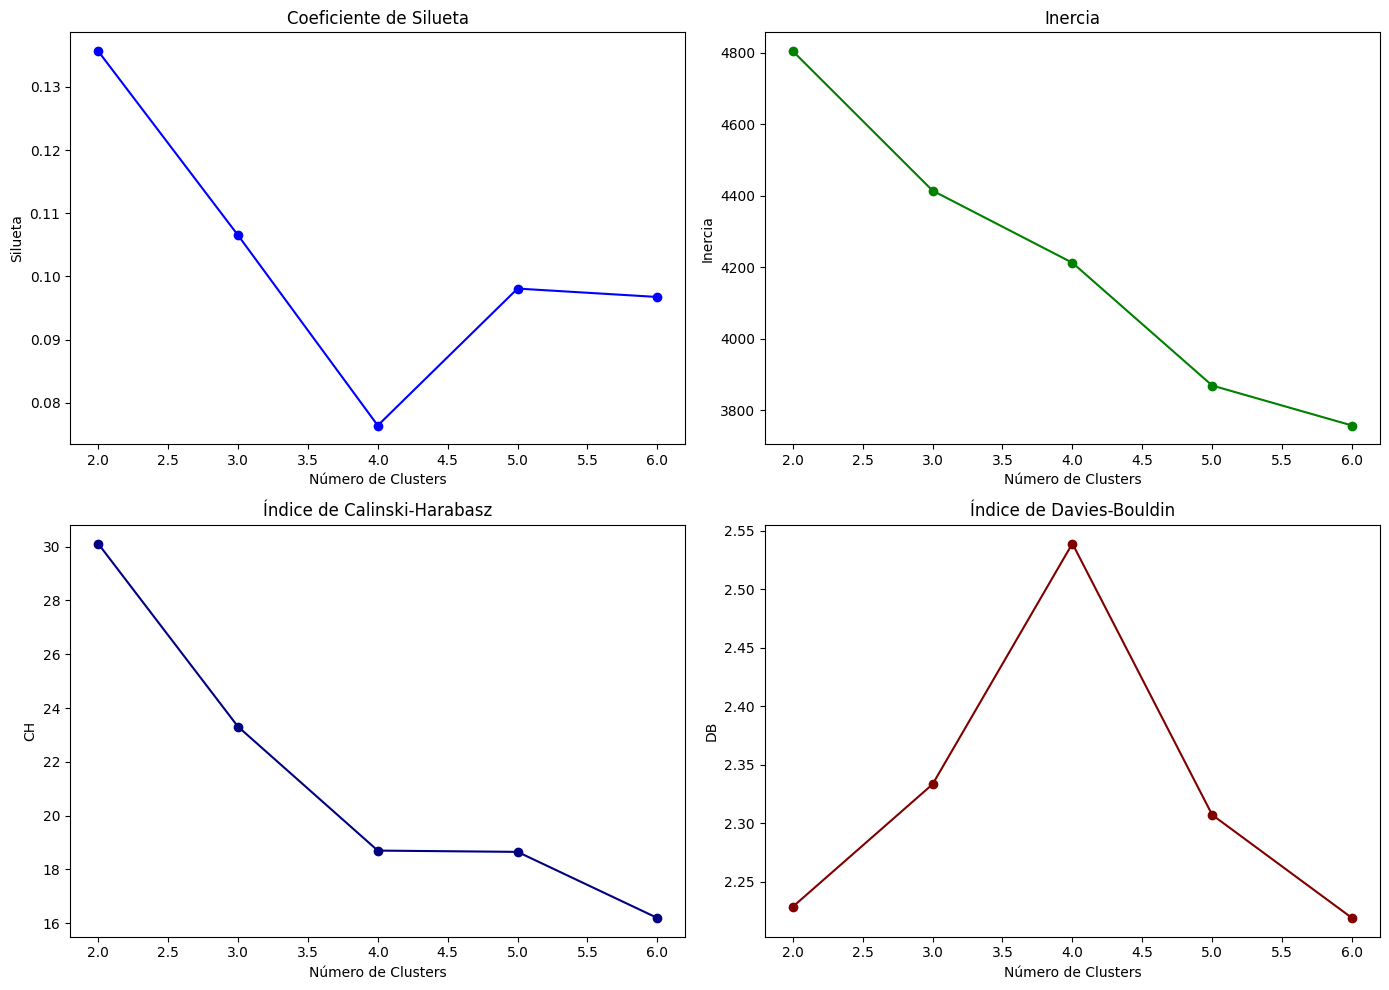

,Clusters,Silueta,Inercia,Calinski-Harabasz,Davies-Bouldin
0,2,0.135649,4804.410852,30.116167,2.228400
1,3,0.106535,4414.329244,23.311480,2.333131
2,4,0.076432,4212.772515,18.701909,2.538843
3,5,0.098087,3869.642521,18.653927,2.306946
4,6,0.096759,3757.972941,16.195832,2.218842


In [38]:
kmeans.optimal_clusters()

## Interpretación de Gráficos

* **Coeficiente de Silueta**. Un valor más alto habla de una mejor separación de los clusters, en este caso aunque mejora un poco el de 5 clusters no supera al de 2.

* **Inercia**. Mide la separación de los puntos con respecto sus centroides, siempre disminuye al aumentar los clusters aunque en este caso el nodo está entre 3 y 4.

* **Índice de Calinski–Harabasz (CH)**. Un valor más alto habla de clusters mejor definidos, nuevamente dos clusters vuelve a ser el mejor grupo de clusters a elegir.

* **Índice de Davies–Bouldin (DB)**. Entre más bajo hay una mejor separación entre clusters, en este caso 2 y 6 son los mejores valores, siendo el peor el de 4 clusters.

In [ ]:
pca = PCA(n_components=0.9)  # conserva 90% de varianza
X_pca = pca.fit_transform(X_scaled)

# Dataset reducido (ya con PCA o escalado)
X_data = X_pca  # si ya usaste PCA
# X_data = X_scaled  # si quieres probar directo con los features escalados

best_score = -1
best_state = None
scores = []

# Probar múltiples semillas
for rs in range(100):  # puedes subirlo a 500 o 1000
    kmeans_ = KMeans(n_clusters=2, random_state=rs, n_init=10)
    labels = kmeans_.fit_predict(X_data)
    score = silhouette_score(X_data, labels)
    scores.append((rs, score))
    
    if score > best_score:
        best_score = score
        best_state = rs

print(f"✅ Mejor silueta: {best_score:.4f} con random_state = {best_state}")

In [ ]:
kmeans.optimal_clusters(11)

In [ ]:
kmeans.fit(n_clusters=2, random_state=11)

In [ ]:
kmeans.plot(data)

In [ ]:
songs1.reset_index(drop=True, inplace=True)

In [ ]:
songs1['cluster'] = kmeans.get_df()['cluster']

In [ ]:
pd.concat([songs1['cluster'].value_counts(), songs1['cluster'].value_counts(normalize=True).apply(lambda x: '{:.1%}'.format(x))], axis=1)

# Playlist personalizada

## Variables significativas para una mejor separación de clusters

In [ ]:
#Definimos un objeto para perfilamiento
class Perfil:
    def __init__(self, df, vars_cat, vars_cont, group_var='cluster'):
        self.df = df
        self.vars_cat = vars_cat
        self.vars_cont = vars_cont
        self.group_var = group_var

    def plot_dist(self, vars_cont: list | None = None):
        if vars_cont is None:
            vars_cont = self.vars_cont
        
        for var in vars_cont:
            plt.figure(figsize=(6, 4))
            sns.kdeplot(data=self.df, x=var, hue=self.group_var, common_norm=False, fill=True, alpha=0.4, palette='viridis')
            plt.title(f'Densidad de {var} por grupos')
            plt.xlabel(var)
            plt.ylabel(None)
            plt.tight_layout()
            plt.show()

    def kw_test(self):
        significativas = []
        for var in self.vars_cont:
            grupos = [grupo[var].dropna() for _, grupo in self.df.groupby(self.group_var)]
            stat, p = kruskal(*grupos)
            #if p < 0.05:
                #significativas.append((var, round(p, 5)))

            significativas.append((var, round(p, 5)))
            
        return pd.DataFrame(significativas, columns=['Variable', 'p-value'])
    
    def group_stats(self, vars):
        df_stats = self.df.groupby('cluster')[vars].agg(['mean', 'median', 'min', 'max'])
        df_stats.columns = ['_'.join(col) for col in df_stats.columns]
        df_stats.reset_index(inplace=True)
        return df_stats

In [ ]:
perfil = Perfil(songs1, var_cat, var_num)

In [ ]:
aux = perfil.kw_test().sort_values(by='p-value', ascending=False).reset_index(drop=True)

var_sig = aux.loc[aux['p-value'] < 0.05, "Variable"].tolist()
var_nosig = aux.loc[aux['p-value'] >= 0.05, "Variable"].tolist()

print('\nVariables no significativas\n')
display(aux.query(f"Variable == {var_nosig}"))

print('\nVariables significativas\n')
display(aux.query(f"Variable == {var_sig}"))

In [ ]:
# Distribución de variables no significativas
perfil.plot_dist(var_nosig)

In [ ]:
# Distribución de variables significativas
perfil.plot_dist(var_sig)

## Creación de variables categóricas para interpretación de resultados

In [ ]:
def inferir_genero(row):
    t = row["tempo_num"]
    zcr = row["zcr"]
    sc = row["spectral_centroid"]

    # Balada
    if t <= 90 and zcr <= 0.1 and sc <= 2000:
        return "Balada / Música lenta"

    # Trap / Drill / Reguetón
    if (70 <= t <= 100 or 140 <= t <= 200) and 0.1 <= zcr <= 0.25 and sc <= 3000:
        return "Trap / Drill / Reguetón"

    # Pop / Rock
    if 100 < t <= 140 and 0.1 < zcr <= 0.3 and 2000 < sc <= 4000:
        return "Pop / Rock"

    # Electrónica / Dance
    if 120 <= t <= 150 and zcr >= 0.2 and sc > 4000:
        return "Electrónica / Dance"

    # Genérico
    return "Popular / Variada"

In [ ]:
# Aplicar al DataFrame
songs1["genero_inferido"] = songs1.apply(inferir_genero, axis=1)

In [ ]:
# Categorías para la variable tempo

bins_tempo = [0, 90, 120, 150, 1000]  # cortes
labels_tempo = ["Lento (≤90)", "Medio (90–120)", "Rápido (120–150)", "Muy rápido (>150)"]

songs1["tempo_cat"] = pd.cut(songs1["tempo_num"], bins=bins_tempo, labels=labels_tempo, ordered=True)

In [ ]:
# Categorías para variable Zero crossing rate

bins_zcr = [0, 0.1, 0.3, 1.0]
labels_zcr = ["Bajo (≤0.1)", "Medio (0.1–0.3)", "Alto (>0.3)"]

songs1["zcr_cat"] = pd.cut(songs1["zcr"], bins=bins_zcr, labels=labels_zcr, ordered=True)

In [ ]:
# Categorías para variable centroid

bins_centroid = [0, 2000, 4000, 10000]  
labels_centroid = ["Oscuro (≤2kHz)", "Equilibrado (2–4kHz)", "Brillante (>4kHz)"]

songs1["centroid_cat"] = pd.cut(songs1["spectral_centroid"], bins=bins_centroid, labels=labels_centroid, ordered=True)

In [ ]:
from pandas.api.types import CategoricalDtype

class playlist:
    def __init__(self, df: pd.DataFrame, other_var: list, group_var: str | list | None = None):
        """
        Genera un resumen estadístico agrupado por una o varias columnas.
    
        Parámetros:
        -----------
        df : pd.DataFrame
            Dataset con las variables.
        other_var : list
            Columna(s) para agregar en la salida agrupada.
        group_var : str o list
            Columna(s) para agrupar (ej. 'cluster' o ['cluster','lang']).
        """
        
        self.df = df
        self.other_var = other_var
        self.group_var = 'cluster' if group_var is None else group_var
    
    def agrupado(self, vars_num: list | None = None, agg: str = "mean", observed: bool = True):
        """
        Genera un resumen estadístico agrupado por una o varias columnas.
    
        Parámetros:
        -----------
        vars_num : list
            Lista de variables numéricas a resumir (si None, usa todas las numéricas).
        agg : str o list
            Agregación a aplicar ('mean', 'median', 'std', 'mode' o lista de funciones).
        
        Retorna:
        --------
        pd.DataFrame con estadísticas agrupadas.
        """
        
        if vars_num is None:
            vars_num = list(set(self.df.select_dtypes(include="number").columns.tolist())-set(self.group_var))
        
        # Si es moda, tratamos distinto porque mode() devuelve varias filas
        if agg == "mode":
            result = self.df.groupby(self.group_var, observed=observed)[vars_num].apply(lambda x: x.mode().iloc[0])
        else:
            result = self.df.groupby(self.group_var, observed=observed)[vars_num].agg(agg)
        
        #return result.reset_index()
        return pd.concat([self.df.groupby(self.group_var, observed=observed).count()['archivo'], result], axis=1) \
                    .rename(columns={'archivo': 'count'}).reset_index()
    
    def resumen(self, agg="mean", observed=True):
        pcolumns = self.other_var + list(set(var_sig)-set(self.other_var)-set(self.group_var))
        
        return self.agrupado(agg=agg, observed=observed)

    def select(self, i, return_count: bool = True):
        features = self.resumen().iloc[i, :].iloc[:4].to_dict()

        # Crear la máscara booleana con "&"
        mask = (
            (self.df["cluster"] == features["cluster"]) &
            (self.df["lang"] == features["lang"]) &
            (self.df["genero_inferido"] == features["genero_inferido"]) &
            (self.df["tempo_cat"] == features["tempo_cat"])
        )

        def str_duration(x: float):
            return f'{int(x/60)} min and {int(x%60)} s'

        df = self.df[mask].copy()
        df['duration_min'] = df['duration'].map(str_duration)
        df['spectral_centroid_kHz'] = df['spectral_centroid']/1000
        df['spectral_rolloff_kHz'] = df['spectral_rolloff']/1000
        
        return df.loc[:, ['archivo', 'lang', 'genero_inferido', 'tempo_cat', 'duration_min', 'zcr', 'spectral_centroid', 'mfcc_7', 'mfcc_1', 'rms', 'mfcc_13', 'spectral_centroid_kHz', 'spectral_rolloff_kHz']]
        

In [ ]:
clase = playlist(
    df=songs1, 
    other_var=['tempo_num','spectral_centroid'],
    group_var=['cluster','lang','genero_inferido','tempo_cat']
)

In [ ]:
clase.agrupado(agg='mean')

## Selección de grupo de canciones

In [ ]:
clase.select(5).sort_values(by=['zcr']).reset_index(drop=True) # seleeción de una fila de la tabla anterior

### Tempo (BPM)

* Música popular: 60–180 BPM.
* Baladas: 60–90 BPM
* Pop/Rock: 100–140 BPM
* Electrónica/Dance: 120–150 BPM
* Trap/Drill/Reguetón: 70–100 BPM (a veces medido en doble tempo → 140–200).

### Zero Crossing Rate (ZCR)

* Normalizado entre 0 y 1.
* Voces limpias o instrumentos suaves: 0.02 – 0.1.
* Sonidos ruidosos/percusión fuerte: 0.1 – 0.3.
* Señales muy ruidosas pueden superar 0.4.

### Spectral Centroid

* Medido en Hz.
* Voces suaves: 1–2 kHz
* Música pop/rock promedio: 2–4 kHz
* Sonidos brillantes (platillos, electrónica): >5 kHz.
* Suele correlacionar con la “brillantez” del sonido.

In [ ]:
def str_duration(x: float):
    return f'{int(x/60)} min and {int(x%60)} s'

In [ ]:
songs1['duration'].describe().loc[['mean','min','25%','50%','75%','max']].map(str_duration)

# Conclusión

El estudio muestra que la mayoría de las canciones analizadas están en idioma inglés y presentan una duración promedio de 3 a 4 minutos, en concordancia con los estándares de la música popular contemporánea. Al examinar los resultados de la segmentación, se observa que, dentro de ciertos clusters que agrupan entre 20 y 40 canciones en inglés, al menos 10 corresponden a artistas reconocidos del pop moderno, como Taylor Swift o Sabrina Carpenter. Este hallazgo no solo refuerza la pertinencia de la categoría inferida “popular/variada”, sino que además aporta evidencia empírica que vincula los clusters obtenidos con tendencias musicales actuales y artistas de referencia en el género.

Algunas variables que podrían enriquecer la interpretación son:

1. Artista
2. Género musical
3. Año de lanzamiento
4. Idioma de la canción (Español, Inglés, etc.)
5. Reproducciones mensuales

Y otras variables que podrían enriquecer el clustering son:

1. **Loudness (LUFS o dBFS)**. Nivel de volumen percibido promedio, ayuda a diferenciar baladas suaves vs. música muy producida y comprimida.
2. **Danceability (0–1)**. Méide cuán adecuada es una pista para bailar según ritmo, estabilidad y beat.
3. **Valence (0–1)**. Mide si la canción transmite emociones positivas (alegría) o negativas (tristeza).
4. **Energy (0–1)**. Similar a RMS pero ajustado a percepción humana; distingue baladas tranquilas de temas electrónicos potentes.
5. **Instrumentalness (0–1)**. Probabilidad de que la pista sea instrumental (sin voz).
6. **Speechiness (0–1)**. Proporción de voz hablada/rap frente a canto melódico.
7. **Acousticness (0–1)**. Probabilidad de que la canción sea acústica vs. electrónica/producida.
8. **Pitch-related features (si quisieras derivar más de Chroma/Tonnetz)**.Porcentaje de notas mayores vs menores, que puede asociarse a emociones.